### Image augmentation

#### This tutorial includes instructions for 
i. manually annotating your images using Napari,        
ii. generating test and traning data        

Follow the steps below to manually annotate your images:

1. Create Shapes layer to select the region of interest (ROI). 
2. Specify face color as transparent, edge width and color of your choise for the Shape layer: 
    For example:
    face color: write "transparent" and press enter
    edge width: press "5" and enter
    edge color: write "blue" and press enter
3. Create Labels layer to annotate fibers (or objects of your interest)
Color fiber borders with a brush and fill the center pressing F and clicking on the center of the fiber
4. Increment label by 1 whenever you draw a label
5. Save regularly the Labels and Shapes layers.
6. Save the image after compeleting manually annotating. 


In [1]:
import matplotlib.pyplot as plt
from skimage.io import imread
from pathlib import Path
import tifffile
import numpy as np
import pandas as pd
import os
import albumentations as A

### Setup: Image preparation

Follow the steps:

1. Upload Shapes, Labels and the image. Check the size of all the annotated images.
2. Save.
3. Once all the images are saved run the augmentations.(Note: Augmentation pipeline run on all the images in the input folder.)

In [6]:
data_path=Path.cwd()
parent_path = data_path/ 'example_img'
label_path = parent_path/ 'labels_shapes'

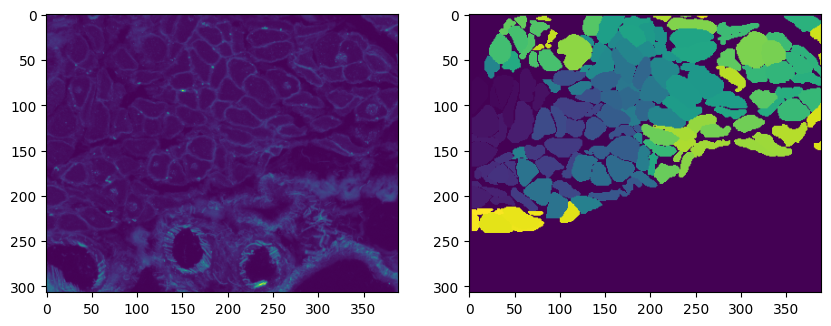

In [7]:
labels = imread(label_path/ 'Labels.tif')
shapes = pd.read_csv(label_path/'Shapes.csv')
image = imread(parent_path/ 'img.tif')

# Extract the coordinates (index 0)
rect_df = shapes[shapes['index'] == 0]
y_coords = rect_df['axis-0'].values
x_coords = rect_df['axis-1'].values

min_row, max_row = int(y_coords.min()), int(y_coords.max())
min_col, max_col = int(x_coords.min()), int(x_coords.max())

cropped = image[min_row:max_row, min_col:max_col]
cropped_labels = labels[min_row:max_row, min_col:max_col]

# Plot the ROI
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(cropped)
plt.subplot(1,2,2)
plt.imshow(cropped_labels)

In [17]:
print("Shape:", cropped_labels.shape)

Shape: (307, 389)


In [8]:
image_dir = os.path.join(parent_path, 'image')
mask_dir = os.path.join(parent_path, 'mask')

os.makedirs(image_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

In [9]:
# save img and masks separately in image and mask dirs, respectivelly
tifffile.imwrite(os.path.join(image_dir, "img_0000.tif"), cropped.astype(np.uint8))
tifffile.imwrite(os.path.join(mask_dir,"img_0000.tif"), cropped_labels.astype(np.uint16))


### Data augmentation

In [10]:
# Shifting, rotation, rescaling, flipping, blurring and elastic deformation were applied to reduce overfitting and increase variability of training data while preserving realistic myofiber architecture. 
# albumentations library are used to generate augmented images-mask pairs 
# More information can be found here: https://albumentations.ai/docs/2-core-concepts/transforms/
TARGET_SIZE = 256

# transform
# p = the probability of applying transformation.
transform = A.Compose([
    A.RandomCrop(height=TARGET_SIZE, width=TARGET_SIZE, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-15, 15), shear=(-5, 5), p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3), # Simulates tissue deformation
    A.GaussianBlur(p=0.3),#  Simulate motion blur, defocus
]) #

In [11]:
# input dir for the image-mask pairs
image_dir = os.path.join(parent_path, 'image')
mask_dir = os.path.join(parent_path, 'mask')

# output dir
aug_image_dir = os.path.join(parent_path, 'augmented_images') 
aug_mask_dir = os.path.join(parent_path, 'augmented_masks')

os.makedirs(aug_image_dir, exist_ok=True)
os.makedirs(aug_mask_dir, exist_ok=True)

# augmentation loop
num_augs_per_image = 10  # generate N augmentations per image

image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.tif')])

for img_name in image_files:
    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)

    # get the augmented image and mask pairs
    image = tifffile.imread(img_path)     
    mask = tifffile.imread(mask_path) 

    for i in range(num_augs_per_image):
        augmented = transform(image=image, mask=mask)
        aug_img = augmented['image']
        aug_mask = augmented['mask']

        base_name = os.path.splitext(img_name)[0]
        aug_img_name = f"{base_name}_aug_{i}.tif"
        aug_mask_name = f"{base_name}_aug_{i}_masks.tif"

        tifffile.imwrite(os.path.join(aug_image_dir, aug_img_name), aug_img.astype(np.uint8))
        tifffile.imwrite(os.path.join(aug_mask_dir, aug_mask_name), aug_mask.astype(np.uint16))


### Next steps

The next steps involve training cpsam using the augmented image-mask pairs.     
This can be done running scripts/020_train-cpsam.py via CLI as described on the myoTrainer README. For more information on traning via CLI, please refer to https://cellpose.readthedocs.io/en/latest/cli.html